# Parallel Chain




## Install dependencies
Run this once in a fresh environment.


In [1]:
# %pip -q install langgraph langchain-openai python-dotenv

## 1) Imports

In [2]:
import os
from dotenv import load_dotenv
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI

## 2) Load environment variables - please read instructions carefully

In [3]:
# if you are running in local, uncomment below line. also make sure you shall have a .env file
load_dotenv()

True

In [4]:
# if you are running in google colab, uncomment below line. and replace "Your_API_Key" with your own openAI API key
#os.environ["OPENAI_API_KEY"] = "Your_API_Key"

## 3) Define Node

In [5]:
llm = ChatOpenAI(
    model="gpt-4.1-mini",
    api_key=os.getenv("OPENAI_API_KEY"),
    temperature=0.4
)

# llm = ChatOpenAI(
#     model="gpt-4.1-mini",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
#     temperature=0.4
# )

class ResearchState(TypedDict):
    topic: str
    market_facts: str
    technology_facts: str
    risk_facts: str
    report: str


def research_market(state: ResearchState):
    try:
        response = llm.invoke(
            f"Research market/business developments about: {state['topic']}"
        )
        return {"market_facts": response.content}
    except Exception as e:
        return {
            "market_facts": "",
            "status": "error",
            "error": f"Research market/business developments failed: {str(e)}"
        }


def research_technology(state: ResearchState):
    try:
        response = llm.invoke(
            f"Research technology developments about: {state['topic']}"
        )
        return {"technology_facts": response.content}
    except Exception as e:
        return {
            "technology_facts": "",
            "status": "error",
            "error": f"Research technology developments failed: {str(e)}"
        }

def research_risk(state: ResearchState):
    try:
        response = llm.invoke(
            f"Research risks and challenges about: {state['topic']}"
        )
        return {"risk_facts": response.content}
    except Exception as e:
        return {
            "risk_facts": "",
            "status": "error",
            "error": f"Research risks and challenges failed: {str(e)}"
        }


def write_report(state: ResearchState):
    prompt = f"""
    Write a concise executive brief based on:

    Market facts:
    {state['market_facts']}

    Technology facts:
    {state['technology_facts']}

    Risks:
    {state['risk_facts']}
    """
    try:
        response = llm.invoke(prompt)
        return {"report": response.content}
    except Exception as e:
        return {
            "report": "",
            "status": "error",
            "error": f"Report failed: {str(e)}"
        }

## 4) Build the parallel chain

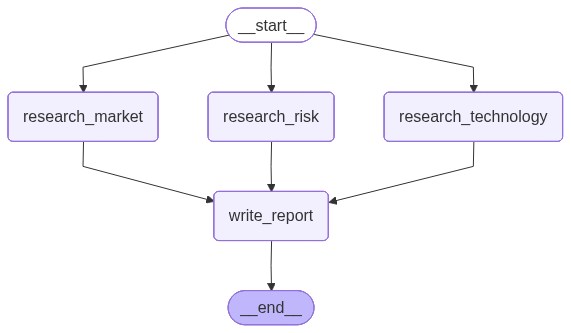

In [6]:
builder = StateGraph(ResearchState)

builder.add_node("research_market", research_market)
builder.add_node("research_technology", research_technology)
builder.add_node("research_risk", research_risk)
builder.add_node("write_report", write_report)

# Fan-out: START triggers 3 nodes in parallel
builder.add_edge(START, "research_market")
builder.add_edge(START, "research_technology")
builder.add_edge(START, "research_risk")

# Fan-in: all 3 nodes flow into the report node
builder.add_edge("research_market", "write_report")
builder.add_edge("research_technology", "write_report")
builder.add_edge("research_risk", "write_report")

builder.add_edge("write_report", END)

graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


## 4) Run

In [7]:
result = graph.invoke({
    "topic": "quantum computing applications in finance"
})

print(result["report"])

**Executive Brief: Quantum Computing Applications in Finance (Mid-2024)**

---

### Market Landscape & Growth Prospects  
Quantum computing is poised to transform financial services by addressing computationally intensive problems beyond classical capabilities. The market is forecasted to grow at a CAGR of 20-30% over the next 5-7 years, potentially reaching several hundred million USD by 2030. This growth is fueled by increased venture capital and corporate investments, with leading financial institutions (e.g., JPMorgan Chase, Goldman Sachs, Barclays) actively funding quantum startups and developing in-house quantum research.

---

### Key Financial Applications  
- **Portfolio Optimization:** Quantum algorithms such as QAOA and VQE are being tested to enhance asset allocation efficiency.  
- **Risk Management:** Quantum Monte Carlo simulations promise accelerated risk assessments and stress testing via Quantum Amplitude Estimation.  
- **Option Pricing & Derivatives:** Quantum metho